In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf
import math
import numpy as np

In [73]:
apple = yf.Ticker("GS").history(period="10y")
price = apple["Close"].reset_index()["Close"]

In [74]:
arr = []
price_len = 50  # 50 days is the sweet spot for pattern matching
step = 1        # Slide 1 day at a time to check all history

for i in range(0, len(price), step):
    # Stop if we don't have a full window left
    if i + price_len > len(price):
        continue

    # Extract window and convert to numpy array
    p = np.array(price[i:i+price_len])
    
    # Z-Score Normalization (Forces mean to 0, standard deviation to 1)
    std_dev = np.std(p)
    if std_dev == 0:
        p = np.zeros(len(p))
    else:
        p = (p - np.mean(p)) / std_dev
        
    arr.append(p)

In [75]:
def compute_dtw_matrix(x, y, window=5):
    N, M = len(x), len(y)
    # Initialize with Infinity
    dtw_matrix = np.full((N + 1, M + 1), np.inf)
    dtw_matrix[0, 0] = 0
    
    # Sakoe-Chiba constraint band
    w = max(window, abs(N - M))
    
    for i in range(1, N + 1):
        # Only calculate within the diagonal band
        for j in range(max(1, i - w), min(M + 1, i + w + 1)):
            cost = abs(x[i - 1] - y[j - 1])
            dtw_matrix[i, j] = cost + min(
                dtw_matrix[i - 1, j],    # insertion
                dtw_matrix[i, j - 1],    # deletion
                dtw_matrix[i - 1, j - 1] # match
            )
    return dtw_matrix

def get_dtw_path_and_steps(dtw_matrix):
    i, j = dtw_matrix.shape[0] - 1, dtw_matrix.shape[1] - 1
    path = [(i - 1, j - 1)]
    
    while i > 1 or j > 1:
        neighbors = {}
        # Only check neighbors that are not infinity
        if dtw_matrix[i - 1, j - 1] != np.inf:
            neighbors["match"] = (i - 1, j - 1, dtw_matrix[i - 1, j - 1])
        if dtw_matrix[i - 1, j] != np.inf:
            neighbors["insert"] = (i - 1, j, dtw_matrix[i - 1, j])
        if dtw_matrix[i, j - 1] != np.inf:
            neighbors["delete"] = (i, j - 1, dtw_matrix[i, j - 1])
            
        best_move = min(neighbors.values(), key=lambda x: x[2])
        i, j = best_move[0], best_move[1]
        path.append((i - 1, j - 1))
        
    path.reverse()
    num_steps = len(path)
    return path, num_steps

In [76]:
# The Target is the MOST RECENT 50 days (to predict tomorrow)
target_window = arr[-1]

# History is everything EXCEPT the target window
historical_arrays = arr[:-price_len]

all_matches = []

# 1. Scan History
for i, hist_window in enumerate(historical_arrays):
    matrix = compute_dtw_matrix(target_window, hist_window, window=5)
    total_distance = matrix[-1, -1]
    
    # If the constraint blocked the match, ignore it completely
    if total_distance == np.inf:
        continue
        
    path, steps = get_dtw_path_and_steps(matrix)
    normalized_score = total_distance / steps
    
    # Store the historical index and its distance score
    all_matches.append((i, normalized_score))

# 2. Sort from lowest (best) distance to highest
all_matches.sort(key=lambda x: x[1])

# 3. Apply the Exclusion Zone to find distinct events
k_matches = 30
final_distinct_matches = []
forbidden_indices = set()

for index, score in all_matches:
    # If this date overlaps with an already chosen match, skip it
    if index in forbidden_indices:
        continue 
        
    final_distinct_matches.append((index, score))
    
    # Block out 50 days before and after this match
    for j in range(index - price_len, index + price_len + 1):
        forbidden_indices.add(j)
        
    # Stop when we have 30 clean matches
    if len(final_distinct_matches) == k_matches:
        break

In [77]:
len(final_distinct_matches)

30

In [78]:
results = [arr[a[0]][-1] for a in  final_distinct_matches]

Based on 30 historical matches:
Win Rate (Probability of Upward Move): 30.00%
Mean Expected Return: -0.62%



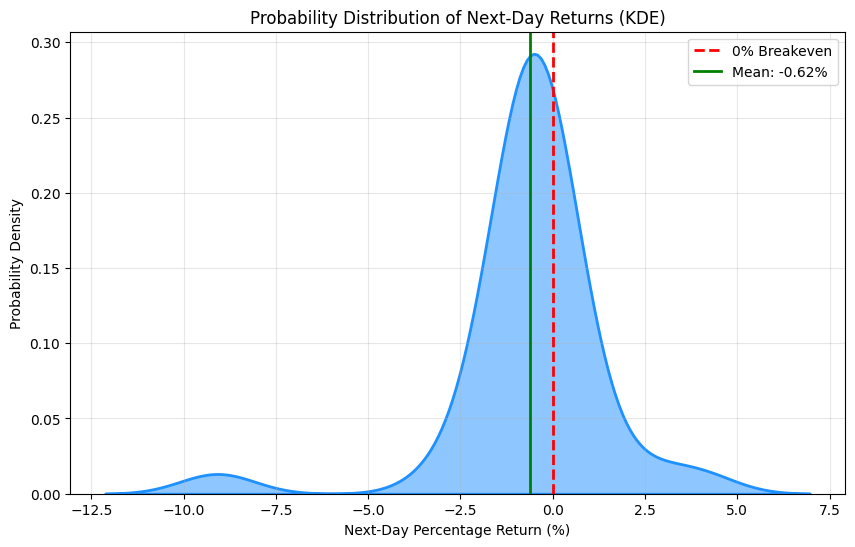

In [79]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 1. Extract the Next-Day Returns
future_returns = []

# Using the matches we found in the last step
for match_index, score in final_distinct_matches:
    # Ensure we don't go out of bounds of our historical data
    if match_index + price_len < len(price):
        # Day 50 is the last day of the pattern
        buy_price = price[match_index + price_len - 1]
        # Day 51 is the future day we are predicting
        sell_price = price[match_index + price_len]
        
        # Calculate percentage change
        pct_change = ((sell_price - buy_price) / buy_price) * 100
        future_returns.append(pct_change)

# Convert to numpy array for math operations
future_returns = np.array(future_returns)

# 2. Calculate the Statistical Edge
# Count how many of those days were strictly positive
win_rate = (np.sum(future_returns > 0) / len(future_returns)) * 100
mean_return = np.mean(future_returns)

print(f"Based on {len(future_returns)} historical matches:")
print(f"Win Rate (Probability of Upward Move): {win_rate:.2f}%")
print(f"Mean Expected Return: {mean_return:.2f}%\n")

# 3. Plot the KDE Bell Curve
plt.figure(figsize=(10, 6))

# seaborn's kdeplot creates the smooth probability distribution
sns.kdeplot(future_returns, fill=True, color="dodgerblue", alpha=0.5, linewidth=2)

# Draw a red vertical line at 0% to clearly separate profits from losses
plt.axvline(0, color='red', linestyle='--', linewidth=2, label='0% Breakeven')

# Draw a green vertical line representing the Mean Expected Return
plt.axvline(mean_return, color='green', linestyle='-', linewidth=2, label=f'Mean: {mean_return:.2f}%')

plt.title('Probability Distribution of Next-Day Returns (KDE)')
plt.xlabel('Next-Day Percentage Return (%)')
plt.ylabel('Probability Density')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()